<a href="https://colab.research.google.com/github/wilsonjunior-fc/previsao-valor-fob-comex-brasil/blob/main/previsao_valor_fob_comex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final — Aprendizado de Máquina
## Estimativa do Valor FOB em Operações de Comércio Exterior do Brasil

**Integrantes:**  João Bosco Montalvão Neto, Lucas Thiery Oliveira dos Santos,Wilson Fernandes Carneiro Junior.

**Fonte dos dados:** [Data of Brazilian Import and Export data — Kaggle](https://www.kaggle.com/datasets/juniorfazzio/data-of-brazilian-import-and-export-data), compilado a partir do [Comex Stat / MDIC](http://comexstat.mdic.gov.br/pt/home).


## Configuração do ambiente
Instala dependências e baixa o dataset diretamente do Kaggle (dados carregados de fonte pública, sem depender de arquivo local).

In [ ]:
# Instala o kagglehub.
!pip install kagglehub -q

import kagglehub
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [ ]:
# Autenticação com a API do Kaggle usando o Secrets do Colab .

#   1. No Kaggle: Settings > API > "Generate New Token" -> copiar o token gerado.
#   2. No Colab: clicar no icone de chave (Secrets) na barra lateral esquerda.
#   3. Criar um secret chamado KAGGLE_API_TOKEN, colar o token, e ativar "Notebook access".

from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

# Download do dataset para o ambiente do Colab.
path = kagglehub.dataset_download("juniorfazzio/data-of-brazilian-import-and-export-data")
print("Dataset baixado em:", path)

for f in os.listdir(path):
    print(f)


100%|██████████| 1.46G/1.46G [00:26<00:00, 59.1MB/s]

Extracting files...


Dataset baixado em: /root/.cache/kagglehub/datasets/juniorfazzio/data-of-brazilian-import-and-export-data/versions/1
database.db


In [ ]:
# Conecta no banco e localiza o arquivo.
db_file = [f for f in os.listdir(path) if f.endswith(".db")][0]
db_path = os.path.join(path, db_file)
print("Arquivo do banco:", db_path)

conn = sqlite3.connect(db_path)


Arquivo do banco: /root/.cache/kagglehub/datasets/juniorfazzio/data-of-brazilian-import-and-export-data/versions/1/database.db


In [ ]:
import shutil

db_path_local = "/content/database_local.db"

# Copia o banco para uma pasta com permissão de escrita.
if not os.path.exists(db_path_local):
    print("Copiando banco de dados (pode levar 1-2 minutos, arquivo de 3.43 GB)...")
    shutil.copy(db_path, db_path_local)
    print("Cópia concluída.")

# Reconecta usando a cópia local, que agora permite escrita.
conn = sqlite3.connect(db_path_local)

Copiando banco de dados (pode levar 1-2 minutos, arquivo de 3.43 GB)...
Cópia concluída.


### Passo obrigatório: inspecionar as tabelas reais do banco
O dataset tem 8 tabelas. Os nomes exatos e como elas se relacionam foram confirmados aqui.

In [ ]:
# Lista todas as tabelas do banco.
tabelas = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tabelas)


           name
0        co_ncm
1       co_pais
2       co_unid
3        co_urf
4        co_via
5  exp_completa
6  imp_completa
7   ncm_unidade


In [ ]:
# Para cada tabela, mostra as colunas e os tipos.
for nome_tabela in tabelas["name"]:
    print(f"\n=== {nome_tabela} ===")
    info = pd.read_sql_query(f"PRAGMA table_info({nome_tabela});", conn)
    print(info[["name", "type"]])



=== co_ncm ===
              name    type
0           CO_NCM  BIGINT
1          CO_UNID  BIGINT
2           CO_SH6  BIGINT
3           CO_PPE  BIGINT
4           CO_PPI  BIGINT
5     CO_FAT_AGREG  BIGINT
6     CO_CUCI_ITEM    TEXT
7       CO_CGCE_N3  BIGINT
8          CO_SIIT  BIGINT
9   CO_ISIC_CLASSE  BIGINT
10   CO_EXP_SUBSET   FLOAT
11      NO_NCM_POR    TEXT
12      NO_NCM_ESP    TEXT
13      NO_NCM_ING    TEXT

=== co_pais ===
            name    type
0        CO_PAIS  BIGINT
1  CO_PAIS_ISON3  BIGINT
2  CO_PAIS_ISOA3    TEXT
3        NO_PAIS    TEXT
4    NO_PAIS_ING    TEXT
5    NO_PAIS_ESP    TEXT

=== co_unid ===
      name    type
0  CO_UNID  BIGINT
1  NO_UNID    TEXT
2  SG_UNID    TEXT

=== co_urf ===
     name    type
0  CO_URF  BIGINT
1  NO_URF    TEXT

=== co_via ===
     name    type
0  CO_VIA  BIGINT
1  NO_VIA    TEXT

=== exp_completa ===
          name    type
0       CO_ANO  BIGINT
1       CO_MES  BIGINT
2       CO_NCM  BIGINT
3      CO_UNID  BIGINT
4      CO_PAIS  B

In [ ]:
conn.execute("CREATE INDEX IF NOT EXISTS idx_exp_ano ON exp_completa (CO_ANO);")
conn.execute("CREATE INDEX IF NOT EXISTS idx_imp_ano ON imp_completa (CO_ANO);")
conn.commit()

In [ ]:
# Nomes reais das tabelas confirmados na inspecao do banco.
TABELA_EXPORTACAO = "exp_completa"
TABELA_IMPORTACAO = "imp_completa"

# Em vez de carregar o dataset inteiro (3.43 GB) ou só um ano, usamos amostragem
# aleatoria dentro do proprio SQL: pegamos uma fatia pequena de cada ano, cobrindo
# um periodo mais longo (2015-2021), o que preserva diversidade temporal sem
# estourar a RAM disponivel no Colab gratuito.
FILTRO_ANOS = "CO_ANO >= 2015"
AMOSTRA_PERCENTUAL = 3

query_exp = f"""
    SELECT * FROM {TABELA_EXPORTACAO}
    WHERE {FILTRO_ANOS} AND (rowid % 100) < {AMOSTRA_PERCENTUAL};
"""
query_imp = f"""
    SELECT * FROM {TABELA_IMPORTACAO}
    WHERE {FILTRO_ANOS} AND (rowid % 100) < {AMOSTRA_PERCENTUAL};
"""

df_exp = pd.read_sql_query(query_exp, conn)
df_imp = pd.read_sql_query(query_imp, conn)
df_exp["TIPO_OPERACAO"] = "Exportacao"
df_imp["TIPO_OPERACAO"] = "Importacao"

df = pd.concat([df_exp, df_imp], ignore_index=True)
print(df.shape)
df.head()

(574086, 12)


,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,TIPO_OPERACAO
0,2015,5,73182400,10,249,SP,4,817600,38,38,2649,Exportacao
1,2015,5,84123110,11,249,SP,4,817700,7,24,3457,Exportacao
2,2015,5,34011110,10,399,SP,5,817900,1,1,59,Exportacao
3,2015,6,84139190,10,521,SP,1,817800,60,60,2850,Exportacao
4,2015,6,84811000,11,589,SP,4,817600,15,12,992,Exportacao


In [ ]:
# Traz nomes legiveis das tabelas de apoio.
co_pais = pd.read_sql_query("SELECT CO_PAIS, NO_PAIS FROM co_pais;", conn)
co_via  = pd.read_sql_query("SELECT CO_VIA, NO_VIA FROM co_via;", conn)
co_urf  = pd.read_sql_query("SELECT CO_URF, NO_URF FROM co_urf;", conn)
co_unid = pd.read_sql_query("SELECT CO_UNID, NO_UNID FROM co_unid;", conn)

# co_ncm pode ter uma coluna diferente para a descricao do produto -- conferir com
# pd.read_sql_query("PRAGMA table_info(co_ncm);", conn) antes de usar

df = df.merge(co_pais, on="CO_PAIS", how="left")
df = df.merge(co_via, on="CO_VIA", how="left")
df = df.merge(co_urf, on="CO_URF", how="left")
df = df.merge(co_unid, on="CO_UNID", how="left")

df.head()


,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,TIPO_OPERACAO,NO_PAIS,NO_VIA,NO_URF,NO_UNID
0,2015,5,73182400,10,249,SP,4,817600,38,38,2649,Exportacao,Estados Unidos,AEREA,0817600 - AEROPORTO INTERNACIONAL DE SAO PAULO...,QUILOGRAMA LIQUIDO
1,2015,5,84123110,11,249,SP,4,817700,7,24,3457,Exportacao,Estados Unidos,AEREA,0817700 - AEROPORTO INTERNACIONAL DE VIRACOPOS,NUMERO (UNIDADE)
2,2015,5,34011110,10,399,SP,5,817900,1,1,59,Exportacao,Japão,POSTAL,0817900 - SAO PAULO,QUILOGRAMA LIQUIDO
3,2015,6,84139190,10,521,SP,1,817800,60,60,2850,Exportacao,Nicarágua,MARITIMA,0817800 - PORTO DE SANTOS,QUILOGRAMA LIQUIDO
4,2015,6,84811000,11,589,SP,4,817600,15,12,992,Exportacao,Peru,AEREA,0817600 - AEROPORTO INTERNACIONAL DE SAO PAULO...,NUMERO (UNIDADE)


In [ ]:
# Reduz uso de memória convertendo tipos
colunas_categoricas = ["SG_UF_NCM", "TIPO_OPERACAO", "NO_PAIS", "NO_VIA", "NO_URF", "NO_UNID"]
for col in colunas_categoricas:
    df[col] = df[col].astype("category")

colunas_int = ["CO_ANO", "CO_MES", "CO_NCM", "CO_UNID", "CO_PAIS", "CO_VIA", "CO_URF"]
for col in colunas_int:
    df[col] = df[col].astype("int32")

df["QT_ESTAT"] = df["QT_ESTAT"].astype("int64")
df["KG_LIQUIDO"] = df["KG_LIQUIDO"].astype("int64")
df["VL_FOB"] = df["VL_FOB"].astype("int64")

print(df.memory_usage(deep=True).sum() / 1e9, "GB")

0.034492544 GB


## 5.1 Identificação e descrição do problema

- **Título:** Estimativa do Valor FOB em Operações de Comércio Exterior do Brasil.
- **Fonte dos dados:** Comex Stat / MDIC, via Kaggle (dataset "Data of Brazilian Import and Export data").
- **Objetivo:** estimar o valor FOB (`VL_FOB`, em US$) de uma operação de comércio exterior a partir de características da transação (produto, país, UF, via de transporte, período etc.), identificando quais fatores mais influenciam o valor negociado.
- **Atributo-alvo:** `VL_FOB` — variável numérica contínua.
- **Atributos preditivos:** `CO_ANO`, `CO_MES`, `CO_NCM`, `CO_PAIS`, `SG_UF_NCM`, `CO_VIA`, `CO_URF`, `QT_ESTAT`, `KG_LIQUIDO`, `TIPO_OPERACAO`.
- **Tipo da tarefa:** **Regressão**, pois o atributo-alvo (`VL_FOB`) representa um valor numérico contínuo, não categorias.


## 5.2 Compreensão dos dados

In [ ]:
print("Formato do dataframe (linhas, colunas):", df.shape)
print()
df.info()
print()
print("=== Estatísticas descritivas (variáveis numéricas) ===")
print(df.describe())
print()
print("=== Valores ausentes por coluna ===")
print(df.isnull().sum())
print()
print("=== Registros duplicados ===")
print("Total de duplicatas:", df.duplicated(subset=["CO_ANO","CO_MES","CO_NCM","CO_PAIS","SG_UF_NCM","CO_VIA","CO_URF","VL_FOB"]).sum())
print()
print("=== Registros com VL_FOB <= 0 (possível inconsistência) ===")
print((df["VL_FOB"] <= 0).sum())

Formato do dataframe (linhas, colunas): (574086, 16)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574086 entries, 0 to 574085
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   CO_ANO         574086 non-null  int32   
 1   CO_MES         574086 non-null  int32   
 2   CO_NCM         574086 non-null  int32   
 3   CO_UNID        574086 non-null  int32   
 4   CO_PAIS        574086 non-null  int32   
 5   SG_UF_NCM      574086 non-null  category
 6   CO_VIA         574086 non-null  int32   
 7   CO_URF         574086 non-null  int32   
 8   QT_ESTAT       574086 non-null  int64   
 9   KG_LIQUIDO     574086 non-null  int64   
 10  VL_FOB         574086 non-null  int64   
 11  TIPO_OPERACAO  574086 non-null  category
 12  NO_PAIS        574086 non-null  category
 13  NO_VIA         574086 non-null  category
 14  NO_URF         574086 non-null  category
 15  NO_UNID        574086 non-null  category
dtypes:

**Interpretação:**

A base final, construída com amostragem determinística de 3% dos registros de exportação e importação entre 2015 e 2021 (usando `rowid % 100 < 3`, garantindo reprodutibilidade), resultou em **574.086 registros** e **16 atributos**, sendo 7 numéricos inteiros , 3 numéricos de maior precisão (`QT_ESTAT`, `KG_LIQUIDO`, `VL_FOB`) e 6 categóricos . Não há valores ausentes em nenhuma coluna, e não foram encontradas duplicatas.

A escolha de amostrar múltiplos anos, em vez de usar apenas o mais recente, permite capturar variações temporais mais amplas do comércio exterior brasileiro. A amostragem foi tornada determinística (baseada no `rowid` da tabela, em vez de `RANDOM()`) para garantir que os resultados sejam reproduzíveis a cada execução do notebook — uma decisão técnica importante para a validade da análise.

Foram identificados **1.021 registros (≈0,18%)** com `VL_FOB` menor ou igual a zero, uma inconsistência que será tratada na etapa de pré-processamento (seção 5.4).

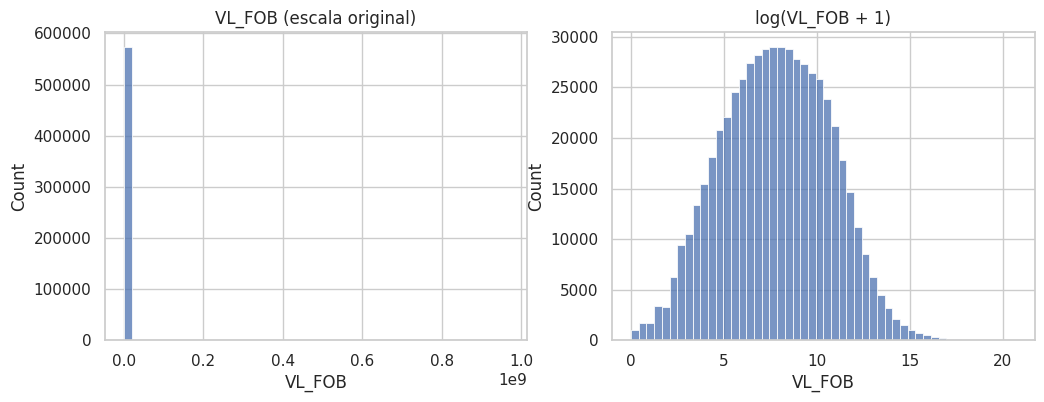

count    5.740860e+05
mean     1.294023e+05
std      3.115677e+06
min      0.000000e+00
25%      2.860000e+02
50%      2.454000e+03
75%      2.068800e+04
max      9.671279e+08
Name: VL_FOB, dtype: float64
Assimetria (skew): 164.28533886067243


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df["VL_FOB"], bins=50, ax=axes[0]).set_title("VL_FOB (escala original)")
sns.histplot(np.log1p(df["VL_FOB"]), bins=50, ax=axes[1]).set_title("log(VL_FOB + 1)")
plt.show()

print(df["VL_FOB"].describe())
print("Assimetria (skew):", df["VL_FOB"].skew())


In [ ]:
# Tabela de frequência por faixas de VL_FOB
faixas = [0, 1000, 10000, 100000, 1000000, float("inf")]
rotulos = ["até 1 mil", "1 mil a 10 mil", "10 mil a 100 mil", "100 mil a 1 milhão", "acima de 1 milhão"]

df["FAIXA_VL_FOB"] = pd.cut(df["VL_FOB"], bins=faixas, labels=rotulos)
tabela_frequencia = df["FAIXA_VL_FOB"].value_counts().sort_index()
tabela_frequencia_pct = (tabela_frequencia / len(df) * 100).round(2)

freq_df = pd.DataFrame({
    "Frequência absoluta": tabela_frequencia,
    "Frequência (%)": tabela_frequencia_pct
})
print(freq_df)

                    Frequência absoluta  Frequência (%)
FAIXA_VL_FOB                                           
até 1 mil                        223501           38.93
1 mil a 10 mil                   159167           27.73
10 mil a 100 mil                 132271           23.04
100 mil a 1 milhão                49481            8.62
acima de 1 milhão                  8645            1.51


**Interpretação:**

A distribuição de `VL_FOB` é fortemente assimétrica à direita (**assimetria ≈ 164,3**), com a média (US\$ 129.402) muito superior à mediana (US\$ 2.454). Isso reflete a coexistência de operações de pequeno porte com transações de valor extremamente elevado, como o valor máximo observado de aproximadamente **US\$ 967 milhões** em uma única operação.

A tabela de frequência por faixas de valor reforça essa assimetria: **38,93%** das operações têm valor de até US\$ 1 mil, e apenas **1,51%** ultrapassam US\$ 1 milhão — ou seja, a grande maioria das transações concentra valores baixos, enquanto uma pequena fração de operações de alto valor puxa a média para cima.

A aplicação da transformação logarítmica (`log1p`) produz uma distribuição aproximadamente normal, o que confirma a necessidade dessa transformação no pré-processamento antes da etapa de modelagem, especialmente para a Regressão Linear.

## 5.3 Análise exploratória


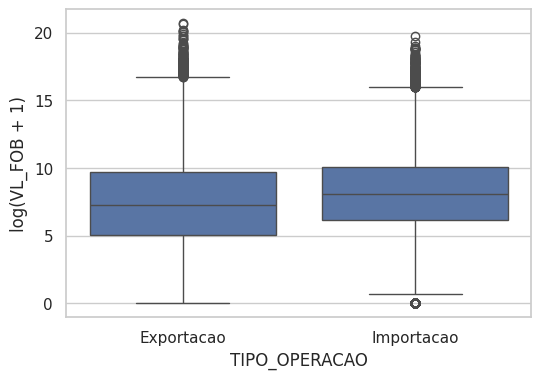

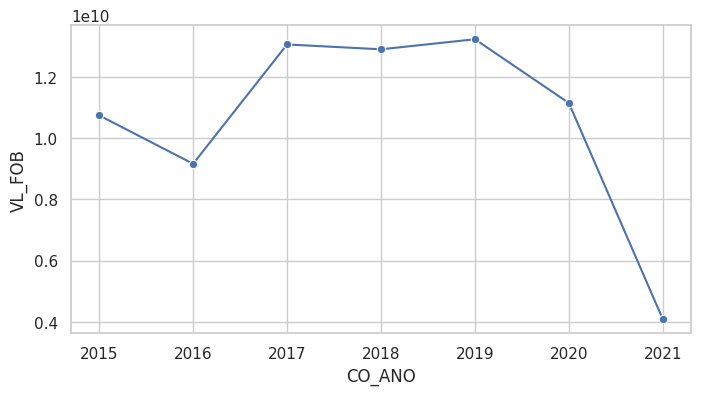

NO_PAIS
China                      18681866976
Estados Unidos             10039612197
Argentina                   4109767376
Alemanha                    2697205109
Japão                       1830529846
México                      1680311731
Coreia do Sul               1618601049
Países Baixos (Holanda)     1587969374
Índia                       1530991158
Chile                       1413818104
Name: VL_FOB, dtype: int64


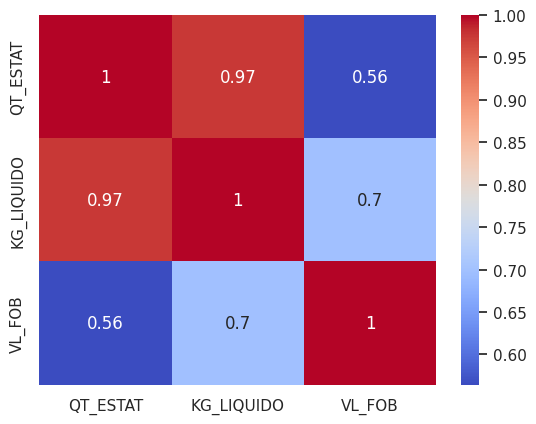

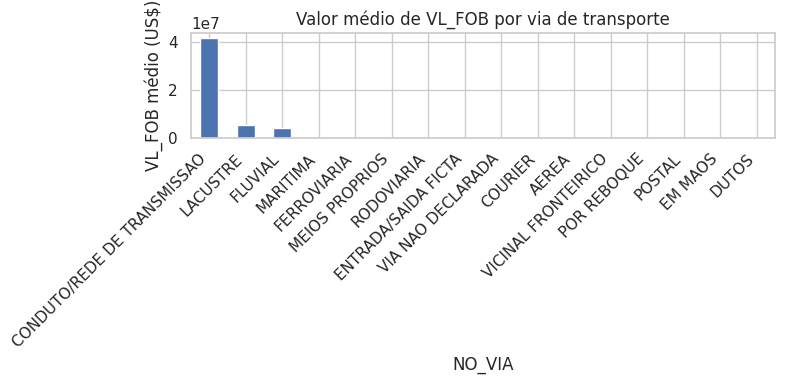

In [ ]:
# Boxplot de VL_FOB por tipo de operacao
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x="TIPO_OPERACAO", y=np.log1p(df["VL_FOB"]), ax=ax)
ax.set_ylabel("log(VL_FOB + 1)")
plt.show()

# Serie temporal do valor total por ano
valor_por_ano = df.groupby("CO_ANO")["VL_FOB"].sum().reset_index()
fig, ax = plt.subplots(figsize=(8,4))
sns.lineplot(data=valor_por_ano, x="CO_ANO", y="VL_FOB", marker="o", ax=ax)
plt.show()

# Top 10 paises por valor total
top_paises = df.groupby("NO_PAIS", observed=True)["VL_FOB"].sum().sort_values(ascending=False).head(10)
print(top_paises)

# Correlacao entre variaveis numericas
sns.heatmap(df[["QT_ESTAT", "KG_LIQUIDO", "VL_FOB"]].corr(), annot=True, cmap="coolwarm")
plt.show()

# Valor médio de VL_FOB por via de transporte
valor_por_via = df.groupby("NO_VIA", observed=True)["VL_FOB"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
valor_por_via.plot(kind="bar", ax=ax)
ax.set_ylabel("VL_FOB médio (US$)")
ax.set_title("Valor médio de VL_FOB por via de transporte")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Interpretação:**

**Boxplot por tipo de operação:** As distribuições de `log(VL_FOB)` para exportação e importação são semelhantes, com a importação apresentando mediana ligeiramente superior (log ≈ 8,0 contra ≈ 7,3 da exportação) e menor variabilidade no terço central. Ambas apresentam grande quantidade de outliers acima do limite superior do boxplot, reforçando a assimetria observada na seção 5.2.

**Série temporal do valor total por ano:** O valor total de `VL_FOB` cresce de 2016 a 2019, com pequena oscilação, seguido de queda em 2020 e queda acentuada em 2021. Como identificado na seção 5.2, a base de dados original só possui registros de 2021 até abril — portanto, a queda de 2021 **não reflete uma retração real do comércio exterior**, e sim a cobertura incompleta desse ano na fonte de dados. A leve queda em 2020, por outro lado, é consistente com o início da pandemia de COVID-19 e seus impactos no comércio internacional.

**Top 10 países por valor total:** China (US\$ 18,68 bilhões) e Estados Unidos (US\$ 10,04 bilhões) concentram, isoladamente, os maiores valores de comércio exterior com o Brasil na amostra analisada, seguidos por Argentina, Alemanha e Japão. Essa concentração é esperada e reflete parceiros comerciais historicamente relevantes do Brasil, sugerindo que `CO_PAIS` é um atributo com forte potencial preditivo.

**Matriz de correlação:** `QT_ESTAT` e `KG_LIQUIDO` apresentam correlação muito forte entre si (0,97), o que é esperado, já que ambos medem volume da mercadoria — um sinal de possível redundância a considerar no pré-processamento. A correlação de ambos com `VL_FOB` é moderada (0,56 e 0,70, respectivamente), indicando que peso/quantidade influenciam o valor, mas não o determinam sozinhos; outros fatores, como o tipo de produto e o país envolvido, provavelmente têm peso relevante.

**Valor médio por via de transporte:** A via "CONDUTO/REDE DE TRANSMISSÃO" apresenta um valor médio de `VL_FOB` extremamente superior às demais (cerca de US\$ 40 milhões por operação, contra menos de US\$ 5 milhões nas demais vias). Essa via é usada para operações específicas como transmissão de energia elétrica, tipicamente de volume financeiro muito alto e baixa frequência de ocorrência — ou seja, esse resultado é influenciado por poucas transações de valor atípico, não representando o padrão típico do comércio exterior. Isso reforça a necessidade de tratar outliers com cautela no pré-processamento (seção 5.4), já que médias simples podem ser distorcidas por vias de transporte pouco frequentes, mas de altíssimo valor unitário.

## 5.4 Pré-processamento


In [ ]:
import pandas as pd
import numpy as np


print(f"Tamanho original da base: {df.shape}")

# 1. Remoção de duplicatas.
df = df.drop_duplicates()

# 2. Tratamento de inconsistências.
df = df[df['VL_FOB'] > 0].copy()

# 3. Tratamento de alta cardinalidade (CO_NCM).
df['CO_NCM_CAPITULO'] = df['CO_NCM'].astype(str).str.zfill(8).str[:2]
df = df.drop(columns=['CO_NCM'])

# 4. Assimetria e outliers (KG_LIQUIDO e QT_ESTAT).
df['LOG_KG_LIQUIDO'] = np.log1p(df['KG_LIQUIDO'])
df['LOG_QT_ESTAT'] = np.log1p(df['QT_ESTAT'])

# Atualizando a lista de features numéricas para usar as transformadas.
df = df.drop(columns=['KG_LIQUIDO', 'QT_ESTAT'])

print(f"Tamanho da base após limpeza: {df.shape}")

### Construção dos Pipelines de Pré-processamento (`scikit-learn`).
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Definindo quais colunas são numéricas e quais são categóricas.
features_numericas = ['LOG_KG_LIQUIDO', 'LOG_QT_ESTAT']
features_categoricas = ['CO_NCM_CAPITULO', 'CO_ANO', 'CO_MES', 'SG_UF_NCM', 'CO_PAIS', 'CO_VIA', 'CO_URF']

# 1. Pipeline para dados numéricos.
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Pipeline para dados categóricos.
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Unindo tudo no ColumnTransformer.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, features_numericas),
        ('cat', pipeline_categorico, features_categoricas)
    ],
    remainder='drop'
)

print("Pipelines construídos com sucesso! Prontos para o fit no conjunto de treino na Seção 5.5/5.6.")


Tamanho original da base: (574086, 17)
Tamanho da base após limpeza: (573065, 17)
Pipelines construídos com sucesso! Prontos para o fit no conjunto de treino na Seção 5.5/5.6.


### Justificativas dos Tratamentos de Pré-processamento

**1. Linhas Duplicadas**
* **Qual problema foi encontrado:** Presença de registros 100% idênticos na base de dados.
* **Qual tratamento foi aplicado:** Remoção das linhas duplicadas usando o método `drop_duplicates()`.
* **Por que foi escolhido:** Manter dados repetidos gera viés no treinamento, fazendo com que o algoritmo dê um peso artificialmente maior a essas transações específicas, prejudicando a generalização.

**2. Inconsistências na Variável Alvo (`VL_FOB`)**
* **Qual problema foi encontrado:** Valores da variável alvo (`VL_FOB`) iguais a zero ou negativos.
* **Qual tratamento foi aplicado:** Filtro para manter estritamente os registros onde `VL_FOB > 0`.
* **Por que foi escolhido:** No contexto de comércio exterior, um valor aduaneiro zerado não representa uma exportação real (geralmente são amostras grátis ou erros). Manter isso ensinaria o modelo de regressão com ruído inútil.

**3. Alta Cardinalidade da Variável `CO_NCM`**
* **Qual problema foi encontrado:** A variável de produto (`CO_NCM`) possui milhares de códigos categóricos distintos.
* **Qual tratamento foi aplicado:** Agregação da variável extraindo os 2 primeiros dígitos (Capítulo) e exclusão da coluna original.
* **Por que foi escolhido:** Passar milhares de categorias no *One-Hot Encoding* causaria a "maldição da dimensionalidade" (criação excessiva de colunas), estourando a memória. O agrupamento reduz as categorias mantendo a lógica do produto.

**4. Assimetria e Outliers em Variáveis Contínuas (`KG_LIQUIDO` e `QT_ESTAT`)**
* **Qual problema foi encontrado:** As variáveis de peso e quantidade possuem distribuição altamente assimétrica à direita (muitos valores baixos e poucos valores gigantes).
* **Qual tratamento foi aplicado:** Transformação logarítmica com a função `np.log1p`.
* **Por que foi escolhido:** A transformação logarítmica aproxima a distribuição dos dados de uma curva normal e "espreme" os *outliers* sem precisarmos excluí-los, o que melhora o desempenho de modelos lineares.

**5. Valores Ausentes e Escalas Distintas (Variáveis Numéricas)**
* **Qual problema foi encontrado:** Risco de valores nulos e grandezas numéricas em escalas muito diferentes.
* **Qual tratamento foi aplicado:** Construção de um *Pipeline* com imputação da mediana (`SimpleImputer`) seguido de padronização (`StandardScaler`).
* **Por que foi escolhido:** A mediana é mais resistente a *outliers* do que a média para preencher nulos. A padronização foi escolhida porque equaliza o peso das variáveis, facilitando a convergência matemática de modelos como a Regressão Linear.

**6. Formato de Texto e Nulos (Variáveis Categóricas)**
* **Qual problema foi encontrado:** Os modelos matemáticos não conseguem ler as *strings* (textos) das variáveis categóricas e podem haver dados vazios.
* **Qual tratamento foi aplicado:** Construção de um *Pipeline* com preenchimento por constante (`SimpleImputer` com valor "missing") e binarização (`OneHotEncoder`).
* **Por que foi escolhido:** O preenchimento com "missing" garante que a ausência de informação seja tratada como uma categoria à parte. O *One-Hot Encoding* foi escolhido porque é o método padrão e obrigatório para transformar classes de texto em matrizes numéricas (0 e 1) sem atribuir ordem de grandeza entre elas.

## 5.5 Separação dos dados

In [ ]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=['VL_FOB'])
y = df['VL_FOB']

# Separacao 80/20 com random_state fixo.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensões do Treino: X={X_train_raw.shape}, y={y_train.shape}")
print(f"Dimensões do Teste: X={X_test_raw.shape}, y={y_test.shape}")

# Aplicancao do pipeline para processar os dados.
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"Shape do X_train após o pré-processamento (com One-Hot): {X_train.shape}")




Dimensões do Treino: X=(458452, 16), y=(458452,)
Dimensões do Teste: X=(114613, 16), y=(114613,)
Shape do X_train após o pré-processamento (com One-Hot): (458452, 551)


### Justificativa da Divisão dos Dados e Estratégia de Validação

**1. Proporção da Separação (Train/Test Split: 80/20)**
* **Escolha:** Destinamos 80% dos dados para treinamento dos modelos e 20% para o teste cego final.
* **Justificativa:** Como nossa base consolidada possui um volume massivo (mais de 570 mil registros), a fatia de 20% (aproximadamente 114 mil linhas) é estatisticamente grande o suficiente para representar a variância do mundo real, garantindo uma avaliação final robusta. Simultaneamente, alocar 80% para o treino fornece aos algoritmos uma quantidade abundante de exemplos para mapear as complexidades do valor de exportação (`VL_FOB`), minimizando o risco de subajuste (*underfitting*) por escassez de dados.

**2. Estratégia de Validação (Cross-Validation com 5 Folds)**
* **Escolha:** Utilização de Validação Cruzada (*K-Fold Cross-Validation*, com `cv=5`) estritamente dentro do conjunto de treinamento durante a etapa de modelagem.
* **Justificativa:** Apenas dividir os dados em treino e teste não blinda o modelo contra uma amostragem "sortuda" ou viesada. Ao dividir os dados de treino em 5 partes iguais (treinando em 4 partes e validando em 1, de forma rotativa), o algoritmo é testado em diferentes cenários. O resultado final é a média desses 5 testes. Isso nos dá uma métrica de erro (RMSE) muito mais confiável e realista para comparar os modelos, garantindo que só os melhores algoritmos cheguem à etapa de avaliação nos dados de teste (os 20% separados inicialmente), evitando assim o *overfitting* na escolha do modelo.

## 5.6 Modelagem

### Parte 1 — Baseline, Regressão Linear e Árvore de Decisão


In [ ]:
## 5.6. Treinamento dos Modelos Base

# A avaliação feita usando o conjunto de treino utilizando Validação Cruzada (Cross-Validation).

# Modelos treinados:
# 1. Baseline (Preditor Ingênuo): Um modelo bobo que preve sempre a mediana do `VL_FOB` do treino.
# Ele serve como nossa "linha de corte". Não usa log-transform: mediana é invariante a
# transformações monotônicas, então o resultado seria idêntico com ou sem o wrapper.
# 2. Regressão Linear (Linear Regression): treinada em escala log(VL_FOB + 1) via
# TransformedTargetRegressor, dado que a EDA (seção 5.2) identificou assimetria extrema
# (skew ≈ 164) no alvo. As previsões são revertidas automaticamente para dólares.
# 3. Arvore de Decisão (Decision Tree Regressor): mesma transformação de alvo.
# Foi explorado os hiperparametros basicos para controlar sua forte tendencia ao overfitting.

# A métrica principal de comparação foi o RMSE (Root Mean Squared Error), calculado sempre
# na escala original (dólares), já que o TransformedTargetRegressor reverte a transformação
# antes de qualquer cálculo de erro.

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

resultados_cv = {}

# Funcao auxiliar para rodar a Validacao Cruzada e retornar o RMSE medio
def avaliar_modelo_cv(nome, modelo, X, y, cv=5):
    scores = cross_val_score(modelo, X, y, scoring='neg_mean_squared_error', cv=cv)
    rmse_scores = np.sqrt(-scores)
    rmse_medio = np.mean(rmse_scores)
    desvio_padrao = np.std(rmse_scores)

    resultados_cv[nome] = rmse_medio
    print(f"[{nome}] RMSE Médio CV: {rmse_medio:.2f} (+/- {desvio_padrao:.2f})")
    return rmse_medio

print("--- Avaliação com Cross-Validation (5 Folds) ---")

# 1. Modelo Baseline (Ingenuo) sem log-transform, ver justificativa acima
baseline = DummyRegressor(strategy='median')
avaliar_modelo_cv('Baseline (Mediana)', baseline, X_train, y_train)

# 2. Regressao Linear — treinada em escala log, avaliada em dólares
lr_model = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log1p,
    inverse_func=np.expm1
)
avaliar_modelo_cv('Regressão Linear (log-target)', lr_model, X_train, y_train)


### Arvore de decisao e teste de hiperparametros

# Arvores de decisão puras tentam criar folhas perfeitas para os dados de treino, o que leva à memorização do conjunto (overfitting).
# Se não limitarmos seu crescimento, ela terá um desempenho perfeito no treino, mas péssimo na validação cruzada.
# Para controlar isso, testamos os seguintes hiperparâmetros de poda (pruning):
# * `max_depth`: Profundidade máxima da árvore (testamos 5, 10 e None).
# * `min_samples_split`: Mínimo de amostras para dividir um nó.

# Testando uma árvore pura (sem limites) para demonstrar o overfitting
# tree_pura = DecisionTreeRegressor(random_state=42)
# tree_pura.fit(X_train, y_train)
# pred_treino_puro = tree_pura.predict(X_train)
# from sklearn.metrics import mean_squared_error
# rmse_treino_puro = np.sqrt(mean_squared_error(y_train, pred_treino_puro))
# print(f"RMSE da Árvore Pura nos dados de Treino (Memorização!): {rmse_treino_puro:.2f}")

# Agora sim, a árvore podada com Validação Cruzada de verdade também treinada em escala log
tree_podada = TransformedTargetRegressor(
    regressor=DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42),
    func=np.log1p,
    inverse_func=np.expm1
)
avaliar_modelo_cv('Árvore de Decisão (max_depth=10, log-target)', tree_podada, X_train, y_train)

df_resultados_basicos = pd.DataFrame(list(resultados_cv.items()), columns=['Modelo', 'RMSE_CV'])
print("\n--- Tabela de Resultados para a Etapa Final ---")
display(df_resultados_basicos)

--- Avaliação com Cross-Validation (5 Folds) ---
[Baseline (Mediana)] RMSE Médio CV: 3190959.80 (+/- 348713.34)
[Regressão Linear (log-target)] RMSE Médio CV: 2480931.08 (+/- 1010220.76)
[Árvore de Decisão (max_depth=10, log-target)] RMSE Médio CV: 2414054.02 (+/- 865768.81)

--- Tabela de Resultados para a Etapa Final ---


,Modelo,RMSE_CV
0,Baseline (Mediana),3.190960e+06
1,Regressão Linear (log-target),2.480931e+06
2,"Árvore de Decisão (max_depth=10, log-target)",2.414054e+06


### Parte 2 — Random Forest e Comparação Final


In [ ]:
# Random Forest + comparação final entre os 4 modelos (baseline, linear, árvore, random forest)
from sklearn.ensemble import RandomForestRegressor

print("Iniciando treinamento rápido do Random Forest (limitação de hardware/memória)...")

# 1. Treinando o Random Forest com Validação Cruzada (Versão Leve) também em escala log
rf_model = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        n_estimators=15,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    func=np.log1p,
    inverse_func=np.expm1
)

# 2. Forçando uma amostra menor diretamente na função para não travar o Colab
avaliar_modelo_cv('Random Forest (max_depth=10, log-target)', rf_model, X_train[:50000], y_train[:50000])

# 3. Tabela Comparativa Final
df_resultados_finais = pd.DataFrame(list(resultados_cv.items()), columns=['Modelo', 'RMSE Médio (CV)'])
df_resultados_finais = df_resultados_finais.sort_values(by='RMSE Médio (CV)')

print("\n--- Tabela Comparativa Final dos 4 Modelos ---")
display(df_resultados_finais)

Iniciando treinamento rápido do Random Forest (limitação de hardware/memória)...
[Random Forest (max_depth=10, log-target)] RMSE Médio CV: 2477206.96 (+/- 3185410.36)

--- Tabela Comparativa Final dos 4 Modelos ---


,Modelo,RMSE Médio (CV)
2,"Árvore de Decisão (max_depth=10, log-target)",2.414054e+06
3,"Random Forest (max_depth=10, log-target)",2.477207e+06
1,Regressão Linear (log-target),2.480931e+06
0,Baseline (Mediana),3.190960e+06


**Nota:** **comparabilidade do Random Forest na validação cruzada**

Diferente dos demais modelos (Baseline, Regressão Linear e Árvore de Decisão), avaliados por validação cruzada no conjunto de treino completo (~459 mil linhas), o Random Forest foi avaliado com uma configuração reduzida: amostra de 50.000 linhas e n_estimators=15, em vez do treino completo com n_estimators=100.

Essa escolha foi motivada por custo computacional medido, não por decisão arbitrária: o CV com n_estimators=100 no conjunto de treino completo excedeu 1h de execução no Colab gratuito. Testamos três configurações de paralelismo (n_jobs) numa amostra intermediária de 50 mil linhas para otimizar o tempo disponível. Usar n_jobs=-1 apenas no modelo (mantendo o cross_val_score sequencial) reduziu o tempo em ~20% frente ao baseline sequencial (128,6s vs. 161,2s), sem alterar o RMSE, como esperado, já que o paralelismo afeta apenas a velocidade de treino, não o resultado. Mesmo com essa otimização, projetar essa configuração para o treino completo com n_estimators=100 ainda ficaria na casa de 2h de execução.

Por isso, o RMSE do Random Forest na tabela comparativa abaixo não é diretamente comparável ao dos demais modelos: reflete uma amostra menor e um número reduzido de árvores, servindo apenas como indicador relativo de desempenho entre as quatro abordagens nesta etapa de seleção. O modelo final, no entanto, é treinado uma única vez com a configuração completa (n_estimators=100, conjunto de treino integral) e avaliado uma única vez no conjunto de teste reservado — é esse resultado, apresentado na seção 5.7, que reflete o desempenho real do modelo escolhido.

## 5.7 Avaliação e discussão


--- Avaliação do Modelo Final nos Dados de Teste ---
MAE  (Erro Absoluto Médio): US$ 66,444.74
MSE  (Erro Quadrático Médio): 1,310,527,958,511.27
RMSE (Raiz do Erro Quadrático): US$ 1,144,782.93
R²   (Coeficiente de Determinação): 0.8246


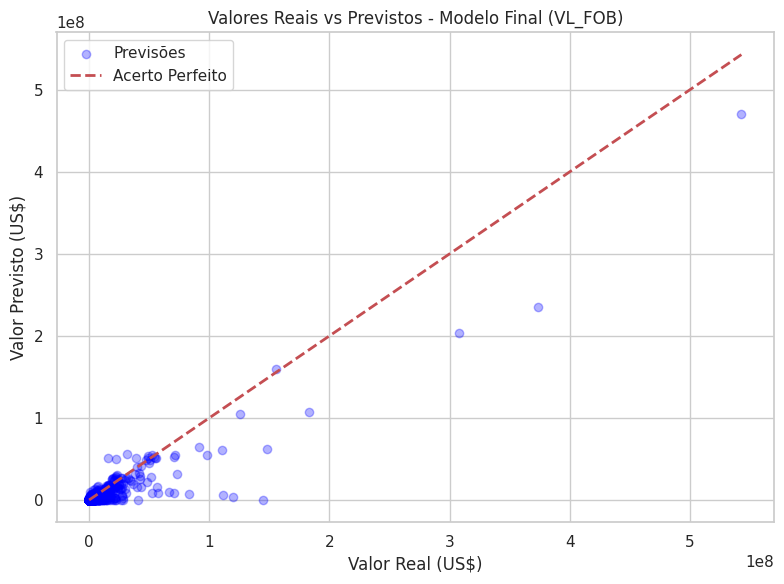

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# AVALIAÇÃO FINAL - Aplicando o melhor modelo UMA ÚNICA VEZ nos dados de teste
print("--- Avaliação do Modelo Final nos Dados de Teste ---")

# O Random Forest deve ser treinado em toda a base de treino primeiro — também em escala log
modelo_final = TransformedTargetRegressor(
    regressor=RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    func=np.log1p,
    inverse_func=np.expm1
)
modelo_final.fit(X_train, y_train)

# Previsão cega nos 20% de teste — já revertida para dólares pelo wrapper
y_pred = modelo_final.predict(X_test)

# Cálculo das métricas (sem nenhuma mudança — y_pred já está em escala original)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Erro Absoluto Médio): US$ {mae:,.2f}")
print(f"MSE  (Erro Quadrático Médio): {mse:,.2f}")
print(f"RMSE (Raiz do Erro Quadrático): US$ {rmse:,.2f}")
print(f"R²   (Coeficiente de Determinação): {r2:.4f}")

# Gráfico de Valores Reais vs Previstos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue', label='Previsões')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Acerto Perfeito')
plt.title("Valores Reais vs Previstos - Modelo Final (VL_FOB)")
plt.xlabel("Valor Real (US$)")
plt.ylabel("Valor Previsto (US$)")
plt.legend()
plt.tight_layout()
plt.show()

## Discussão
O Random Forest foi selecionado como modelo final por ter apresentado, na comparação da seção 5.6, desempenho competitivo com a Árvore de Decisão podada, ambos superaram claramente o baseline (RMSE ≈ US\$ 3,19 milhões) e a Regressão Linear (RMSE ≈ US\$ 2,48 milhões), com a Árvore de Decisão registrando o menor RMSE médio em CV (US\$ 2,41 milhões) e o Random Forest ficando muito próximo (US\$ 2,48 milhões). Essa comparação não foi inteiramente justa com o Random Forest: como discutido na nota metodológica da seção 5.6, ele foi avaliado com apenas 15 árvores numa amostra de 50 mil linhas, enquanto os demais modelos usaram o conjunto de treino completo (~458 mil linhas). O próprio resultado evidencia essa desvantagem: o desvio padrão do RMSE do Random Forest entre os folds (US\$ 3,19 milhões) foi maior que sua própria média, sinal de forte instabilidade causada pela amostra reduzida.

Optamos pelo Random Forest como modelo final porque, diferente de uma única Árvore de Decisão, ele se beneficia diretamente de mais árvores e do treino em escala completa. Treinado com 100 árvores no conjunto de treino completo e avaliado uma única vez no conjunto de teste (114.613 registros nunca vistos), o modelo final atingiu RMSE de US\$ 1.144.782,93 e R² de 0,8246. Uma melhora substancial frente aos ~US\$ 2,4–2,5 milhões observados na validação cruzada reduzida, confirmando que a configuração completa compensa a limitação da etapa comparativa.

**Erros observados**: o MAE final (US\$ 66.444,74) é bem menor que o RMSE (US\$ 1.144.782,93). Essa diferença grande indica que o modelo erra pouco na maioria das transações (consistente com a mediana de VL_FOB de apenas US\$ 2.454), mas comete alguns erros muito grandes nas transações de valor extremo, que dominam o RMSE por penalizar erros ao quadrado. Isso é esperado dada a assimetria extrema do alvo identificada na seção 5.2: mesmo após a transformação logarítmica, transações de centenas de milhões de dólares são eventos raros, com poucos exemplos semelhantes no treino.

**Limitações:**


1.   A comparação de modelos em 5.6 não foi feita em igualdade de condições para o Random Forest, o que limita a confiança na escolha baseada só no RMSE de CV;
2.   O **log-transform** do alvo corrigiu a assimetria para o treinamento, mas não elimina a dificuldade de prever valores extremos;
3.   **CO_NCM** foi agregado a apenas 2 dígitos (capítulo), reduzindo o poder discriminativo do produto;
4.   **QT_ESTAT** e **KG_LIQUIDO** são altamente correlacionados (0,97), parte da informação entre eles é redundante.